# chapter 12: Biological Data Visualization: Matplotlib & Seaborn

## A – Why Data Visualization?

Visualization turns numerical data into interpretable patterns.


Data visualization helps us:
- Understand the distribution of biological measurements 
- Compare different sample groups 
- Identify variability and potential outliers 
- Detect patterns and trends 
- Communicate biological findings more effectively

## B- Matplotlib Fundamentals

Matplotlib is a Python library used to create data visualizations and scientific plots.

It helps us turn numerical data into visual forms such as:
- Bar charts → comparing groups
- Line plots → showing trends
- Scatter plots → exploring relationships
- Boxplots → comparing distributions

In our biological analysis
We use Matplotlib to visualize information such as:

How many samples are present in each biological group?


- Load our Data Preparation from previous chapter:

In [2]:
# %pip install matplotlib

In [3]:
# %pip install seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
analysis_df = pd.read_csv(
    "../data/processed/breast_cancer_gene_expression.csv"
)

analysis_df.head()

,Gene_Symbol_Clean,Sample_ID,Expression,Sample_Title,Group
0,BRCA1,GSM1588970,5.146020,"""TNBC, TUM001_repA""",TNBC
1,ERBB2,GSM1588970,2.927462,"""TNBC, TUM001_repA""",TNBC
2,ESR1,GSM1588970,2.295359,"""TNBC, TUM001_repA""",TNBC
3,MKI67,GSM1588970,8.157279,"""TNBC, TUM001_repA""",TNBC
4,TP53,GSM1588970,4.523142,"""TNBC, TUM001_repA""",TNBC


Before analyzing gene expression, we should understand the structure of our dataset.

In [6]:
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 890 entries, 0 to 889
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gene_Symbol_Clean  890 non-null    str    
 1   Sample_ID          890 non-null    str    
 2   Expression         890 non-null    float64
 3   Sample_Title       890 non-null    str    
 4   Group              890 non-null    str    
dtypes: float64(1), str(4)
memory usage: 34.9 KB


In [7]:
print(analysis_df.shape)
print(analysis_df.isna().sum())

(890, 5)
Gene_Symbol_Clean    0
Sample_ID            0
Expression           0
Sample_Title         0
Group                0
dtype: int64


### 0- plt.figure() — Creating a Figure
What is it? A Figure is the main container or canvas that holds our plot.
- plt.figure(figsize=(width, height)



### 1- Bar Chart — Comparing Groups
What is it? A bar chart compares the size or count of different categories.

- plt.bar(x, height):
- x → categories 
- height → values for each category 


When do we use it?
- Compare biological groups
- Compare sample counts
- Compare gene expression between a few categories
- Show categorical data



#### ❗️ Simple example1:

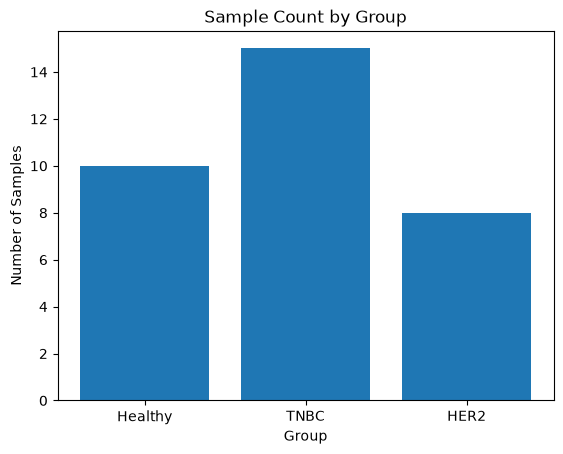

In [8]:
groups = ["Healthy", "TNBC", "HER2"]
samples = [10, 15, 8]

plt.bar(groups, samples)

plt.xlabel("Group")
plt.ylabel("Number of Samples")
plt.title("Sample Count by Group")

plt.show()

#### 🦠 Biological example1:

How many samples belong to each group?

In [9]:
group_counts = analysis_df.drop_duplicates(
    "Sample_ID"
)["Group"].value_counts()

group_counts

Group
TNBC         55
Her2         39
Luminal B    30
Luminal A    29
CellLine     14
Healthy      11
Name: count, dtype: int64

In [10]:
type(group_counts)

pandas.Series

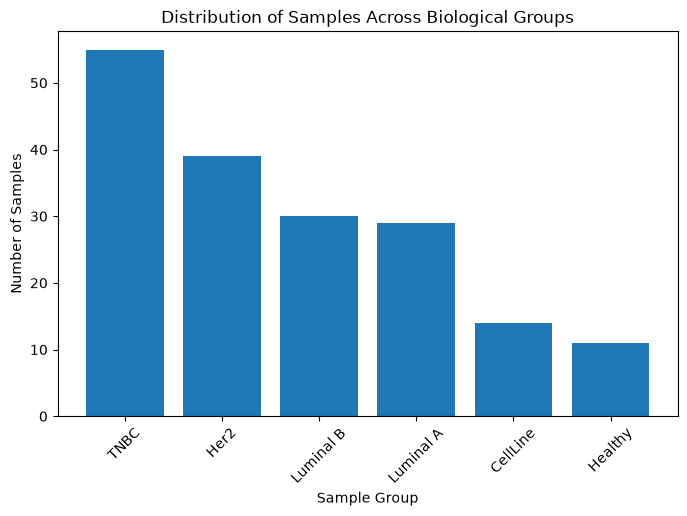

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    group_counts.index,
    group_counts.values
)

plt.xlabel("Sample Group")
plt.ylabel("Number of Samples")
plt.title("Distribution of Samples Across Biological Groups")

plt.xticks(rotation=45)

plt.show()

#### 📊 Interpretation of the above plot:

This simple bar chart helps us understand:
- Sample size
- Group composition
- Potential imbalance between groups


Matplotlib usually works very easily with raw data such as lists, arrays, and numpy.ndarrays. Matplotlib can also work with DataFrames.

In [12]:
analysis_df

,Gene_Symbol_Clean,Sample_ID,Expression,Sample_Title,Group
0,BRCA1,GSM1588970,5.146020,"""TNBC, TUM001_repA""",TNBC
1,ERBB2,GSM1588970,2.927462,"""TNBC, TUM001_repA""",TNBC
2,ESR1,GSM1588970,2.295359,"""TNBC, TUM001_repA""",TNBC
3,MKI67,GSM1588970,8.157279,"""TNBC, TUM001_repA""",TNBC
4,TP53,GSM1588970,4.523142,"""TNBC, TUM001_repA""",TNBC
...,...,...,...,...,...
885,BRCA1,GSM1589153,6.732730,"""CellLine, MDA-MB-231""",CellLine
886,ERBB2,GSM1589153,2.279290,"""CellLine, MDA-MB-231""",CellLine
887,ESR1,GSM1589153,2.332209,"""CellLine, MDA-MB-231""",CellLine
888,MKI67,GSM1589153,8.780097,"""CellLine, MDA-MB-231""",CellLine


- plt.bar() is appropriate when each category has one value.
- When each category contains multiple observations, directly passing all observations to plt.bar() causes bars to overlap at the same categorical position, making the underlying distribution difficult to interpret.

<BarContainer object of 890 artists>

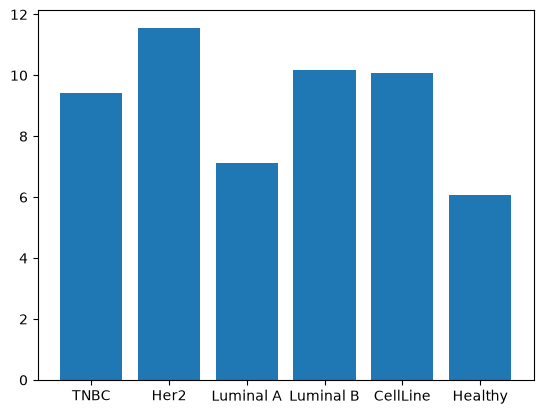

In [13]:
plt.bar(
    analysis_df["Group"],
    analysis_df["Expression"]
)

### 2- Line Plot — Showing Trends


What is it? A line plot shows how a value changes across an ordered variable, often time.

When do we use it?
- Time-series data
- Changes over time
- Experimental progression
- Gene expression across treatment days
- Growth curves

Main function : plt.plot(x, y)
- x → Ordered variable 
- y → Measured value



#### ❗️ Simple example2:

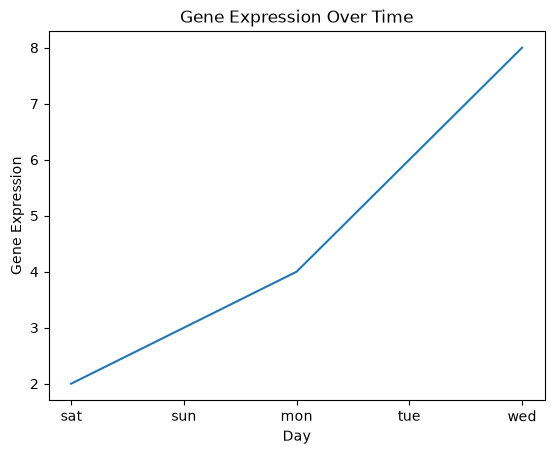

In [21]:
days = ["sat", "sun", "mon", "tue", "wed"]
expression = [2, 3, 4, 6, 8]

plt.plot(days, expression)

plt.xlabel("Day")
plt.ylabel("Gene Expression")
plt.title("Gene Expression Over Time")

plt.show()

### 3- Scatter Plot — Exploring Relationships


What is it? A scatter plot shows the relationship between two numerical variables.
Each point represents one observation.

When do we use it?
- Explore correlations
- Compare two measurements
- Investigate biological relationships
- Identify patterns or outliers

Main function : plt.scatter(x, y)
- x → First numerical variable
- y → Second numerical variable


#### ❗️ Simple example3:

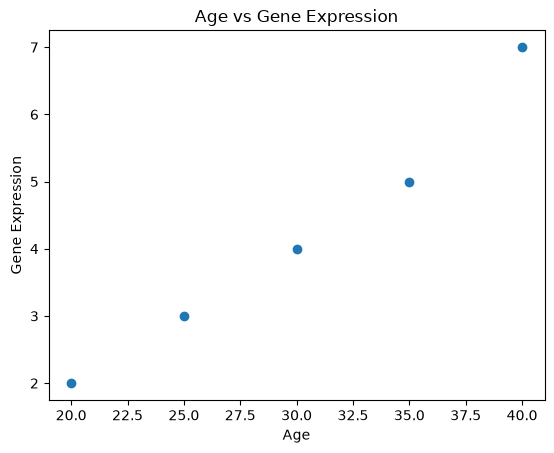

In [22]:
age = [20, 25, 30, 35, 40]
expression = [2, 3, 4, 5, 7]

plt.scatter(age, expression)

plt.xlabel("Age")
plt.ylabel("Gene Expression")
plt.title("Age vs Gene Expression")

plt.show()

### 4- Boxplot — Comparing Distributions



What is it? A boxplot summarizes the distribution of numerical data.

It helps us compare:
- Median
- Variability
- Quartiles
- Possible outliers

Main function : plt.boxplot(x)
- x → Numerical data to visualize


#### ❗️ Simple example4:

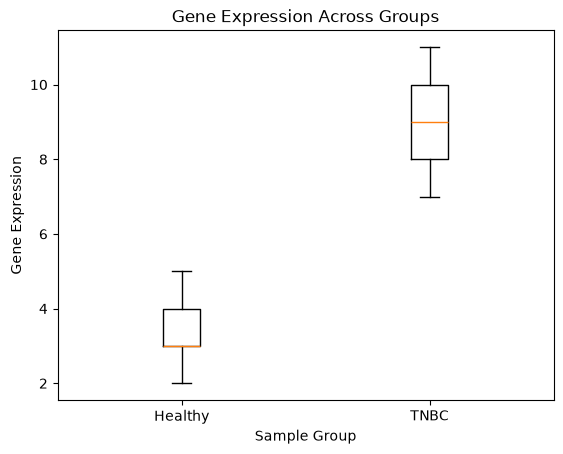

In [23]:
healthy = [2, 3, 4, 3, 5]
tnbc = [7, 8, 10, 9, 11]

plt.boxplot(
    [healthy, tnbc],
    tick_labels=["Healthy", "TNBC"]
)

plt.xlabel("Sample Group")
plt.ylabel("Gene Expression")
plt.title("Gene Expression Across Groups")

plt.show()

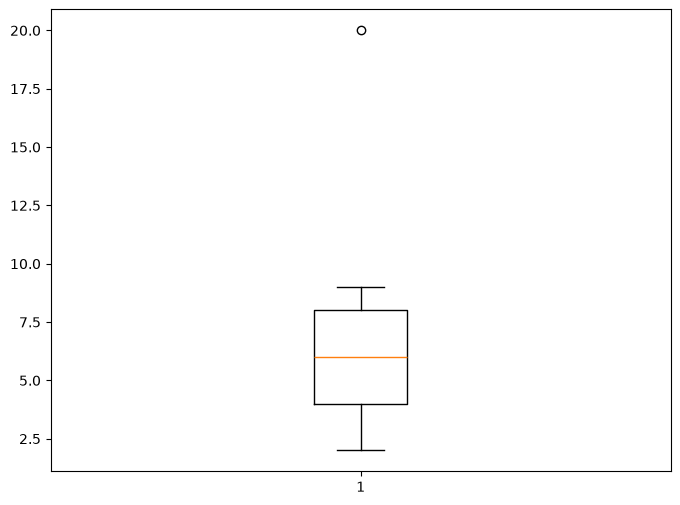

In [24]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [2, 3, 4, 5, 6, 7, 8, 9, 20]
)
plt.show()

❌ Whisker does not necessarily reach the actual minimum and maximum.

#### BoxPlot
A boxplot summarizes the distribution of a numerical variable using its median, quartiles, variability, and potential outliers.


```text
Median (Q2)      → 50th percentile
Q1               → 25th percentile
Q3               → 75th percentile
IQR              → Q3 − Q1
Box              → Middle 50% of observations
Whiskers         → Values within 1.5 × IQR
Potential Outlier → Value beyond the whisker limits

```

#### 🦠 Biological example2:

Does ESR1 expression differ between Healthy and TNBC samples?

1- Select ESR1

In [25]:
esr1_df = analysis_df[
    analysis_df["Gene_Symbol_Clean"] == "ESR1"
].copy()

esr1_df.head()


,Gene_Symbol_Clean,Sample_ID,Expression,Sample_Title,Group
2,ESR1,GSM1588970,2.295359,"""TNBC, TUM001_repA""",TNBC
7,ESR1,GSM1588971,2.342138,"""TNBC, TUM001_repB""",TNBC
12,ESR1,GSM1588972,2.343721,"""Her2, TUM002_repA""",Her2
17,ESR1,GSM1588973,2.369953,"""Her2, TUM002_repB""",Her2
22,ESR1,GSM1588974,2.273175,"""TNBC, TUM003""",TNBC


2- Select Healthy and TNBC

In [26]:
esr1_healthy_tnbc = esr1_df[
    esr1_df["Group"].isin(["Healthy", "TNBC"])
].copy()

esr1_healthy_tnbc.head()

,Gene_Symbol_Clean,Sample_ID,Expression,Sample_Title,Group
2,ESR1,GSM1588970,2.295359,"""TNBC, TUM001_repA""",TNBC
7,ESR1,GSM1588971,2.342138,"""TNBC, TUM001_repB""",TNBC
22,ESR1,GSM1588974,2.273175,"""TNBC, TUM003""",TNBC
27,ESR1,GSM1588975,2.352816,"""TNBC, TUM004""",TNBC
32,ESR1,GSM1588976,2.346591,"""TNBC, TUM005""",TNBC


In [27]:
esr1_healthy_tnbc["Group"].value_counts()

Group
TNBC       55
Healthy    11
Name: count, dtype: int64

3- Extract Expression Values

In [28]:
healthy_esr1 = esr1_healthy_tnbc[
    esr1_healthy_tnbc["Group"] == "Healthy"
]["Expression"].values

tnbc_esr1 = esr1_healthy_tnbc[
    esr1_healthy_tnbc["Group"] == "TNBC"
]["Expression"].values

In [29]:
print(healthy_esr1)
print("++++++++++++++++++++++++++++++++++++++++++")
print(tnbc_esr1)

[2.41797893 2.41218664 2.33292143 2.36530369 2.48092687 2.41734327
 2.33449846 2.31173058 2.41585909 2.3704095  2.36224959]
++++++++++++++++++++++++++++++++++++++++++
[2.29535889 2.3421379  2.2731754  2.35281625 2.34659114 2.30214732
 2.29833358 2.34811381 2.36201265 2.29701508 2.27170657 2.3278671
 2.32096732 2.46848137 2.37858641 2.34244878 2.23504964 2.29817667
 2.28522478 2.33896093 2.33252887 2.35549841 2.2883618  2.28419001
 2.35531678 2.32626229 2.30913055 2.3213435  2.31409832 2.31364744
 2.34866848 2.35973364 2.35793671 2.36719052 2.27602297 2.24851792
 2.36820012 2.36328535 2.37460645 2.30853262 2.29268544 2.31039376
 2.30640687 2.36438243 2.27535061 2.34119688 2.29549679 2.37060619
 2.35051278 2.3046641  2.27466352 2.34330366 2.29316016 2.313413
 2.29662139]


4- Visualize with Matplotlib

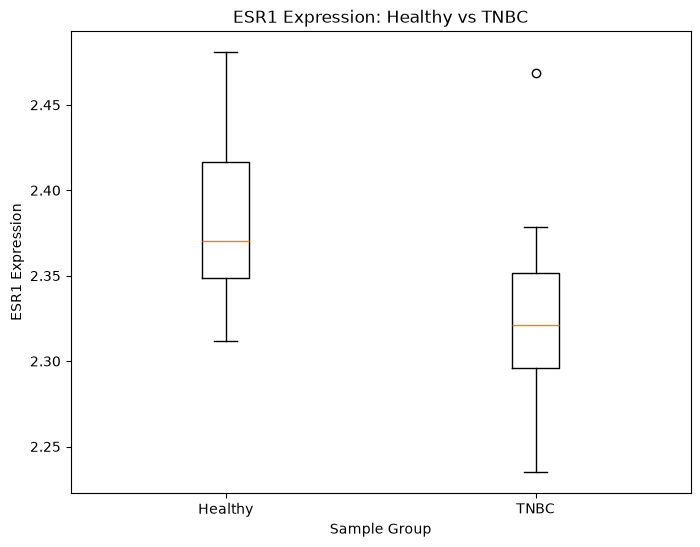

In [30]:
plt.figure(figsize=(8, 6))

plt.boxplot(
    [healthy_esr1, tnbc_esr1],
    tick_labels=["Healthy", "TNBC"]
)

plt.xlabel("Sample Group")
plt.ylabel("ESR1 Expression")
plt.title("ESR1 Expression: Healthy vs TNBC")

plt.show()

```text
                         Expression
                             ↑
                             │
                             │        ○  ← Potential Outlier
                             │
                             │     ─────────  ← Upper Whisker
                             │         │
                             │      ┌───────┐
                             │      │       │
                             │      │   ─   │ ← Median (Q2)
                             │      │       │
                             │      │       │
                             │      └───────┘
                             │        ↑   ↑
                             │       Q1   Q3
                             │
                             │      ←─────→
                             │         IQR
                             │      (Q3 − Q1)
                             │
                             │     ─────────  ← Lower Whisker
                             │
                             └──────────────────→
                                   Sample Group
```

#### 📊 Interpretation of the above plot:
ESR1 expression appears to be higher in Healthy samples than in TNBC samples, with a lower median expression in TNBC. This pattern is biologically consistent with the estrogen-receptor-negative phenotype of TNBC. However, statistical testing is required to determine whether the observed difference is significant.

- Bar → Compare
- Line → Trend
- Scatter → Relationship
- Boxplot → Distribution



## C- Seaborn Fundamentals

Seaborn: Statistical Data Visualization : Seaborn is a Python library for creating statistical and informative data visualizations.

- 📊 Create statistical plots easily 
- 📦 Visualize data distributions 
- 🔬 Explore relationships in biological data 
- 🐼 Works naturally with Pandas DataFrames 
- 🎨 Provides clean and informative default styles 

Seaborn = Statistical visualization made easier with Python and Pandas.

### Matplotlib vs. Seaborn

Matplotlib gives us the building blocks for visualization, while Seaborn provides high-level statistical plots that work naturally with structured data.



1- barplot in both of them:

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.DataFrame({
    "Group": [
        "TNBC", "TNBC", "TNBC",
        "Healthy", "Healthy", "Healthy"
    ],
    "Expression": [
        2, 4, 1, 
        8, 10, 7
    ]
})

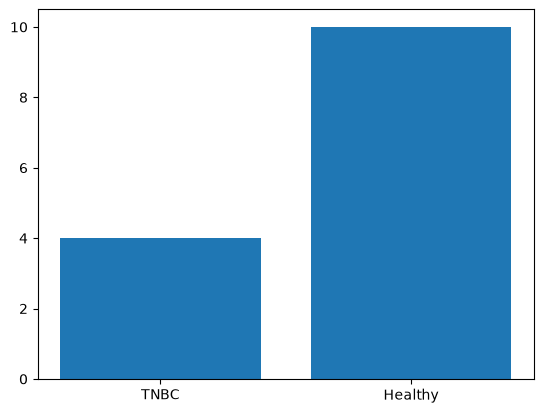

In [59]:
plt.bar(
    df["Group"],
    df["Expression"]
)

plt.show()

<Axes: xlabel='Group', ylabel='Expression'>

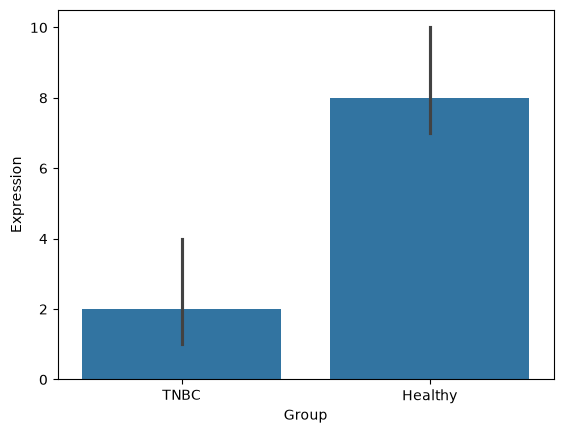

In [ ]:
sns.barplot(
    data=df,
    x="Group",
    y="Expression",
    #estimator="median",
    #errorbar="ci"
    #errorbar=None

)

```text
Seaborn (By default) Data
                 ↓
          Group by "Group"
                 ↓
       ┌─────────┴─────────┐
       ↓                   ↓
     TNBC                Healthy
   [2,4,1]              [8,10,7]
       ↓                   ↓
     Mean                Mean
      2.33                8.33
       ↓                   ↓
      Bar                 Bar
       +                   +
      CI                  CI

```

<BarContainer object of 890 artists>

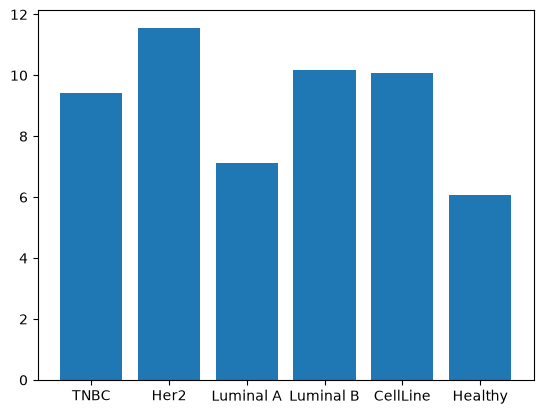

In [66]:
plt.bar(
    analysis_df["Group"],
    analysis_df["Expression"]
)

plt.bar() is appropriate when each category has one value.
When each category contains multiple observations, directly passing all observations to plt.bar() causes bars to overlap at the same categorical position, making the underlying distribution difficult to interpret.


<Axes: xlabel='Group', ylabel='Expression'>

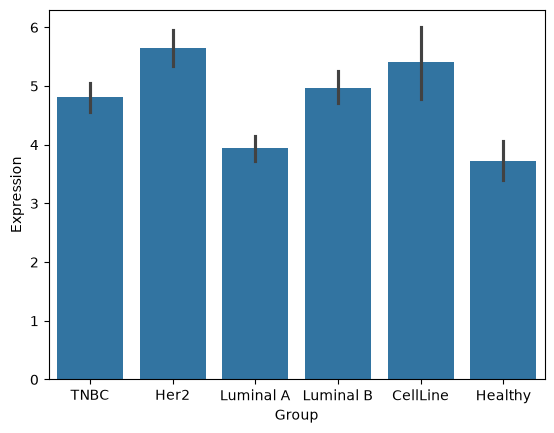

In [ ]:
sns.barplot(
    data=analysis_df,
    x="Group",
    y="Expression",
    #errorbar="ci"
)

#### Countplot

```text
plt.bar()
    ↓
I already have X and Y values.
Just draw them.


sns.barplot()
    ↓
I have categories + numerical observations.
Summarize the numerical values for each category.


sns.countplot()
    ↓
I want to count observations in each category.

```

<Axes: xlabel='Group', ylabel='count'>

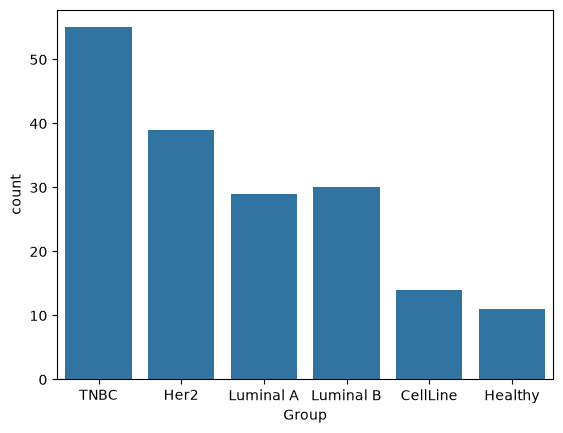

In [65]:
sns.countplot(
    data=analysis_df.drop_duplicates("Sample_ID"),
    x="Group"
)

2- use both of them:

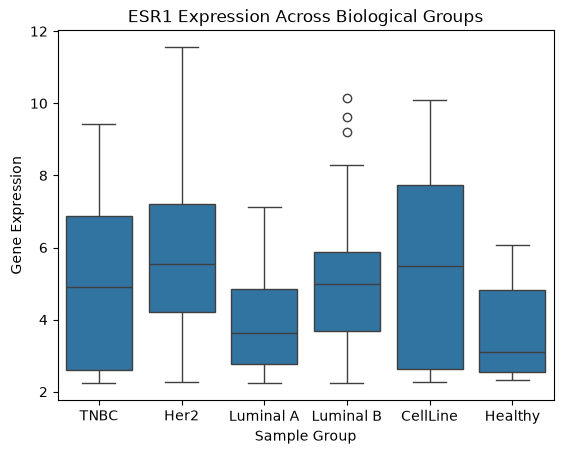

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=analysis_df,
    x="Group",
    y="Expression"
)

plt.xlabel("Sample Group")
plt.ylabel("Gene Expression")
plt.title("ESR1 Expression Across Biological Groups")

plt.show()

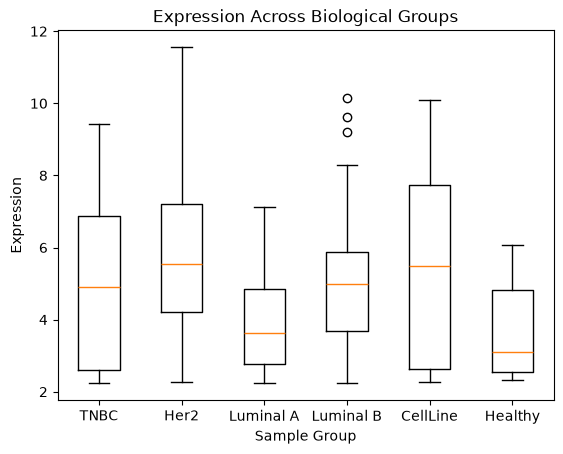

In [67]:
groups = analysis_df["Group"].unique()

data = [
    analysis_df.loc[analysis_df["Group"] == group, "Expression"]
    for group in groups
]

plt.boxplot(data)

plt.xticks(
    range(1, len(groups) + 1),
    groups
)

plt.xlabel("Sample Group")
plt.ylabel("Expression")
plt.title("Expression Across Biological Groups")

plt.show()

| Feature                                    | Matplotlib      | Seaborn           |
| ------------------------------------------ | --------------- | ----------------- |
| **List**                                   | ✅               | ✅                 |
| **NumPy Array**                            | ✅               | ✅                 |
| **Pandas DataFrame**                       | ✅               | ⭐ Very convenient |
| **Working with DataFrame columns by name** | Less convenient | ⭐ Very convenient |
| **Statistical plots**                      | Basic           | ⭐⭐⭐ Advanced      |
| **Level of abstraction**                   | Lower-level     | Higher-level      |


### 1- Boxplot — Comparing Distributions


Use it when:
You want to compare the distribution of a numerical variable across different groups.
It helps us compare:
- Median
- Variability
- Quartiles
- Possible outliers

Main function : 
```text
sns.boxplot(
    data=df,
    x="Group",
    y="Expression"
)
```

| Argument | Meaning              |
| -------- | -------------------- |
| `data`   | DataFrame            |
| `x`      | Categorical variable |
| `y`      | Numerical variable   |


#### ❗️ Simple example5:

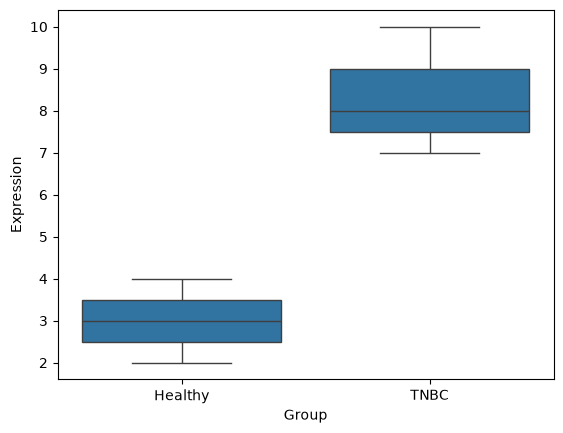

In [34]:
df = pd.DataFrame({
    "Group": [
        "Healthy", "Healthy", "Healthy",
        "TNBC", "TNBC", "TNBC"
    ],
    "Expression": [
        2, 3, 4,
        7, 8, 10
    ]
})

sns.boxplot(
    data=df,
    x="Group",
    y="Expression"
)

plt.show()

#### 🦠 Biological example3:

How does the distribution of gene expression differ between biological groups? (for example ESR1 gene)

<Axes: xlabel='Group', ylabel='Expression'>

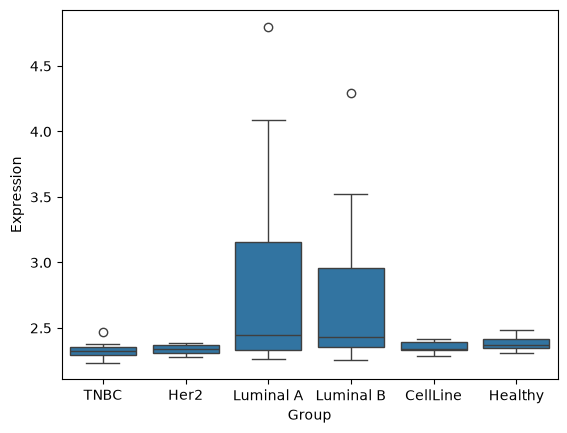

In [35]:
sns.boxplot(
    data=analysis_df[analysis_df["Gene_Symbol_Clean"] == "ESR1"],
    x="Group",
    y="Expression"
)

#### 📊 Interpretation of the above plot:

ESR1 expression is relatively consistent in TNBC, Her2, CellLine, and Healthy groups, while Luminal A and Luminal B show substantially higher variability and expression levels, with several high-expression outliers.

What if we did the previous example with matplotlib and did it with Seaborn? It's much easier and shorter. Because it works much better with dataframes.

In [36]:
esr1_healthy_tnbc

,Gene_Symbol_Clean,Sample_ID,Expression,Sample_Title,Group
2,ESR1,GSM1588970,2.295359,"""TNBC, TUM001_repA""",TNBC
7,ESR1,GSM1588971,2.342138,"""TNBC, TUM001_repB""",TNBC
22,ESR1,GSM1588974,2.273175,"""TNBC, TUM003""",TNBC
27,ESR1,GSM1588975,2.352816,"""TNBC, TUM004""",TNBC
32,ESR1,GSM1588976,2.346591,"""TNBC, TUM005""",TNBC
...,...,...,...,...,...
842,ESR1,GSM1589144,2.334498,"""Healthy, H11""",Healthy
847,ESR1,GSM1589145,2.311731,"""Healthy, H15""",Healthy
862,ESR1,GSM1589148,2.415859,"""Healthy, H4""",Healthy
872,ESR1,GSM1589150,2.370409,"""Healthy, H14""",Healthy


<Axes: xlabel='Group', ylabel='Expression'>

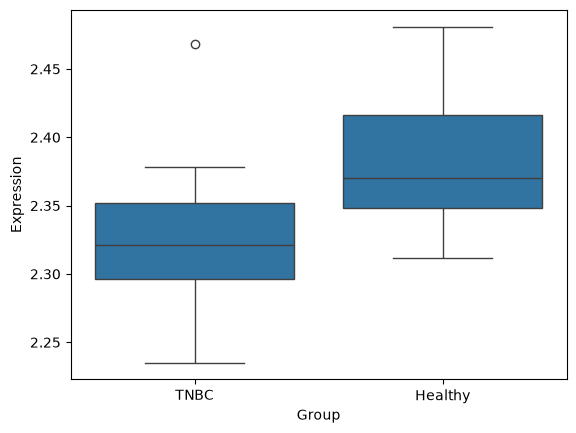

In [37]:
sns.boxplot(
    data=esr1_healthy_tnbc,
    x="Group",
    y="Expression"
)

### 2- Scatter Plot — Exploring Relationships

Use it when:
You want to explore the relationship between two numerical variables.

Main function :
```text
sns.scatterplot(
    data=df,
    x="Age",
    y="Expression"
)

```



| Argument | Meaning                   |
| -------- | ------------------------- |
| `data`   | DataFrame                 |
| `x`      | First numerical variable  |
| `y`      | Second numerical variable |
| `hue`    | Color points by category  |
| `style`  | Different marker styles   |


#### ❗️ Simple example6:

Age vs gene expression

Simple illustrative data for exploring the relationship between two numerical variables.

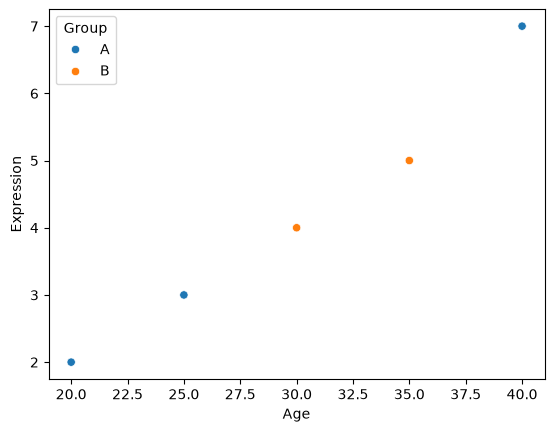

In [38]:
df = pd.DataFrame({
    "Age": [20, 25, 30, 35, 40],
    "Expression": [2, 3, 4, 5, 7],
    "Group": ["A", "A", "B", "B", "A"]
})

sns.scatterplot(
    data=df,
    x="Age",
    y="Expression",
    #hue="Group"
    hue="Group"
)

plt.show()

#### Correlation


| **−1**                           | **0**                     | **+1**                           |
| -------------------------------- | ------------------------- | -------------------------------- |
| **Perfect Negative Correlation** | **No Linear Correlation** | **Perfect Positive Correlation** |




#### 🦠 Biological example4:

Scatterplot is for Numerical → Numerical

Are the Expression of Two Genes Related? For example, ESR1 and MKI67.
analysis_df :
```text
The problem is that ESR1 and MKI67 are in two separate rows.

But the Scatterplot needs something like this for each point:

Sample     ESR1     MKI67
GSM001     8.2      5.4
GSM002     7.8      6.1
GSM003     2.1      8.7

Because each point must have a pair (x, y):

GSM001 → (8.2, 5.4)
GSM002 → (7.8, 6.1)
GSM003 → (2.1, 8.7)
```


So how do we create gene_df?

We can use analysis_df with pivot:

In [39]:
gene_df = analysis_df[
    analysis_df["Gene_Symbol_Clean"].isin(["ESR1", "MKI67"])
].pivot(
    index=["Sample_ID", "Group"],
    columns="Gene_Symbol_Clean",
    values="Expression"
).reset_index()

In [40]:
gene_df

Gene_Symbol_Clean,Sample_ID,Group,ESR1,MKI67
0,GSM1588970,TNBC,2.295359,8.157279
1,GSM1588971,TNBC,2.342138,8.140961
2,GSM1588972,Her2,2.343721,5.473577
3,GSM1588973,Her2,2.369953,4.734367
4,GSM1588974,TNBC,2.273175,7.606273
...,...,...,...,...
173,GSM1589149,CellLine,2.405442,6.872672
174,GSM1589150,Healthy,2.370409,2.863197
175,GSM1589151,Healthy,2.362250,2.831567
176,GSM1589152,CellLine,2.399644,6.467678


Are the Expression of Two Genes Related? For example, ESR1 and MKI67.


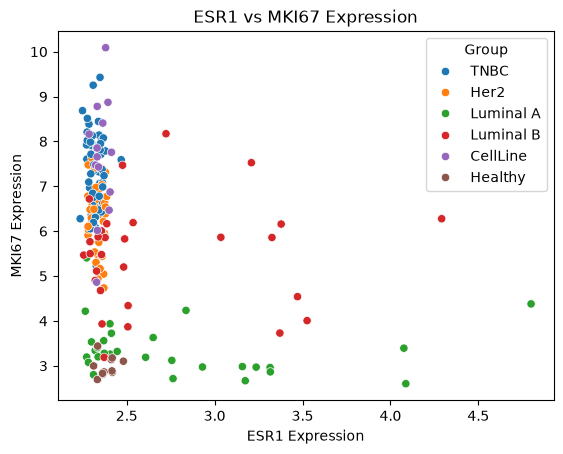

In [ ]:
sns.scatterplot(
    data=gene_df,
    x="ESR1",
    y="MKI67",
    #hue="Group"
)

plt.xlabel("ESR1 Expression")
plt.ylabel("MKI67 Expression")
plt.title("ESR1 vs MKI67 Expression")

plt.show()

In [42]:
gene_df[["ESR1", "MKI67"]].corr()

Gene_Symbol_Clean,ESR1,MKI67
Gene_Symbol_Clean,,
ESR1,1.000000,-0.330912
MKI67,-0.330912,1.000000


#### 📊 Interpretation of the above plot:

The scatter plot does not show a clear linear relationship between ESR1 and MKI67 expression. Most samples are concentrated within a narrow ESR1 range, while MKI67 shows greater variation. The apparent clustering suggests that biological groups may contribute to the observed pattern.

### 3- Histogram — Visualizing a Distribution

Use it when:
You want to see how numerical values are distributed..

Main function
```text
sns.histplot(
    data=df,
    x="Expression",
    bins=5
)
```


| Argument | Meaning                    |
| -------- | -------------------------- |
| `data`   | DataFrame                  |
| `x`      | Numerical variable         |
| `bins`   | Number of intervals        |
| `kde`    | Add a smooth density curve |


#### ❗️ Simple example7:

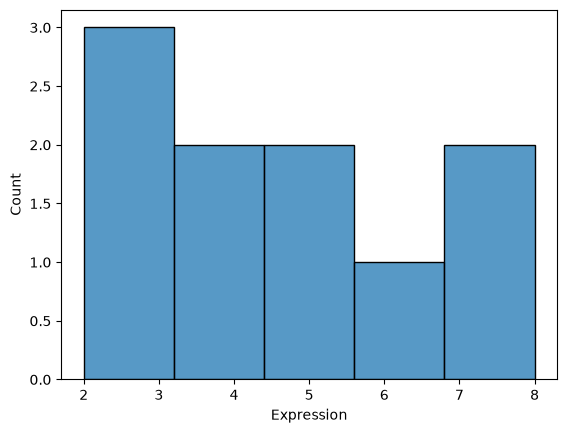

In [43]:
df = pd.DataFrame({
    "Expression": [
        2, 3, 3, 4, 4,
        5, 5, 6, 7, 8
    ]
})

sns.histplot(
    data=df,
    x="Expression",
    bins=5
)

plt.show()

#### 🦠 Biological example5:
Is the expression of ESR1 normally distributed, skewed, or concentrated in a specific range?



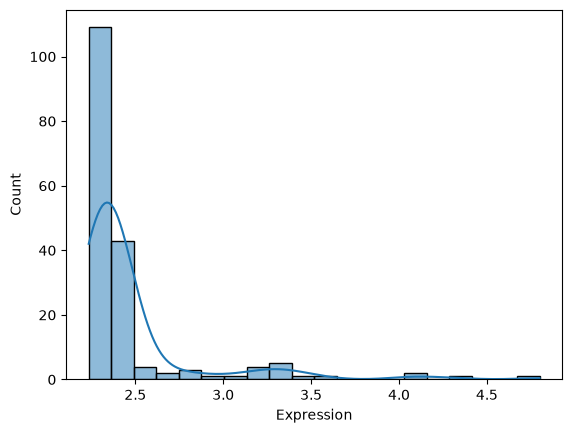

In [44]:
esr1_df = analysis_df[
    analysis_df["Gene_Symbol_Clean"] == "ESR1"
]

sns.histplot(
    data=esr1_df,
    x="Expression",
    bins=20,
    kde=True
)

plt.show()

#### 📊 Interpretation of the above plot:

The ESR1 expression distribution appears to be right-skewed (positively skewed), with most observations concentrated at lower expression values and a longer tail toward higher values.


### 4- Barplot — Comparing Categories
Use it when:
You want to compare a numerical value across categories.

Main function : sns.barplot()


⚠️ Important difference
A barplot usually shows a statistical estimate, such as the mean, for each category, rather than simply displaying individual values.


#### ❗️ Simple example8:

- Healthy → mean(Expression)
- TNBC    → mean(Expression)


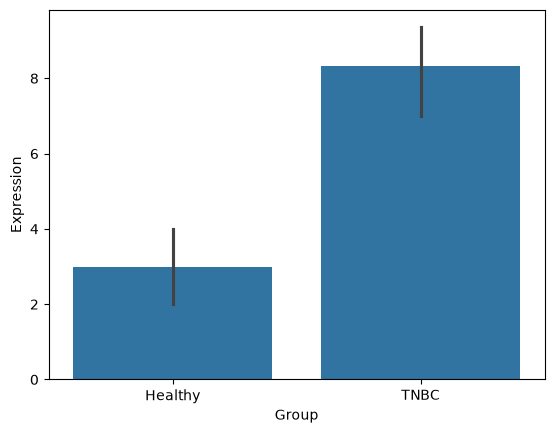

In [45]:
df = pd.DataFrame({
    "Group": [
        "Healthy", "Healthy", "Healthy",
        "TNBC", "TNBC", "TNBC"
    ],
    "Expression": [
        2, 3, 4,
        7, 8, 10
    ]
})

sns.barplot(
    data=df,
    x="Group",
    y="Expression"
)

plt.show()

#### 🦠 Biological example6:
Which biological group has a higher average ESR1 expression?

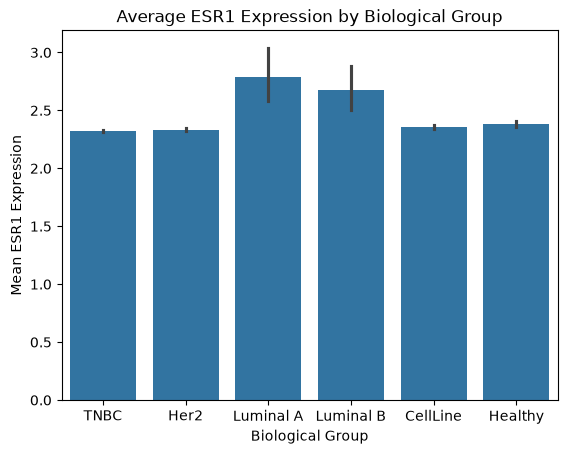

In [46]:
esr1_df = analysis_df[
    analysis_df["Gene_Symbol_Clean"] == "ESR1"
]

sns.barplot(
    data=esr1_df,
    x="Group",
    y="Expression",
    estimator="mean",
    errorbar="ci"
)

plt.title("Average ESR1 Expression by Biological Group")
plt.xlabel("Biological Group")
plt.ylabel("Mean ESR1 Expression")

plt.show()

#### 📊 Interpretation of the above plot:

The Luminal A group shows the highest average ESR1 expression, while TNBC shows lower average expression.

         │
          │   ← Confidence Interval
    ┌──┴──┐
    │           │
    │ BAR   │ ← Mean Expression
    │          │
    └─────┘


### 5- Heatmap — Visualizing Matrices
Use it when:
You want to visualize values in a matrix, where color represents the magnitude of each value.

Main function : sns.heatmap()



| Argument     | Meaning                  |
| ------------ | ------------------------ |
| `data`       | Matrix / DataFrame       |
| `annot=True` | Show values inside cells |
| `cmap`       | Color map                |
| `linewidths` | Space between cells      |
| `fmt`        | Number formatting        |


#### ❗️ Simple example9:

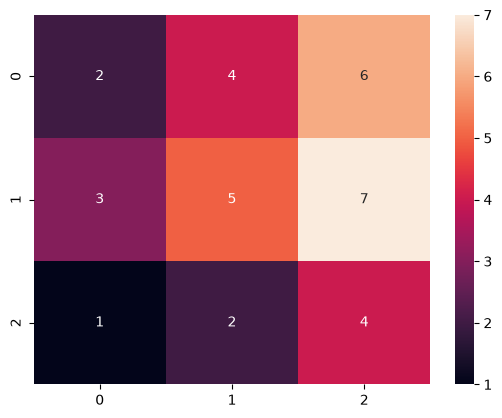

In [47]:
matrix = [
    [2, 4, 6],
    [3, 5, 7],
    [1, 2, 4]
]

sns.heatmap(
    matrix,
    annot=True
)

plt.show()

#### 🦠 Biological example7:
Which genes or samples show relatively high or low expression?


In [48]:
analysis_df

,Gene_Symbol_Clean,Sample_ID,Expression,Sample_Title,Group
0,BRCA1,GSM1588970,5.146020,"""TNBC, TUM001_repA""",TNBC
1,ERBB2,GSM1588970,2.927462,"""TNBC, TUM001_repA""",TNBC
2,ESR1,GSM1588970,2.295359,"""TNBC, TUM001_repA""",TNBC
3,MKI67,GSM1588970,8.157279,"""TNBC, TUM001_repA""",TNBC
4,TP53,GSM1588970,4.523142,"""TNBC, TUM001_repA""",TNBC
...,...,...,...,...,...
885,BRCA1,GSM1589153,6.732730,"""CellLine, MDA-MB-231""",CellLine
886,ERBB2,GSM1589153,2.279290,"""CellLine, MDA-MB-231""",CellLine
887,ESR1,GSM1589153,2.332209,"""CellLine, MDA-MB-231""",CellLine
888,MKI67,GSM1589153,8.780097,"""CellLine, MDA-MB-231""",CellLine


We need Expression Matrix / wide format


In [49]:
expression_matrix = analysis_df.pivot_table(
    index="Gene_Symbol_Clean",
    columns="Sample_ID",
    values="Expression",
    aggfunc="median"
)

expression_matrix

Sample_ID,GSM1588970,GSM1588971,GSM1588972,GSM1588973,GSM1588974,GSM1588975,GSM1588976,GSM1588977,GSM1588978,GSM1588979,...,GSM1589144,GSM1589145,GSM1589146,GSM1589147,GSM1589148,GSM1589149,GSM1589150,GSM1589151,GSM1589152,GSM1589153
Gene_Symbol_Clean,,,,,,,,,,,,,,,,,,,,,
BRCA1,5.146020,5.185623,4.858957,4.965389,5.599303,5.314665,5.026228,4.106809,3.433590,3.449265,...,4.815827,4.794461,6.221208,5.947847,5.243057,6.503696,4.719080,4.632007,5.698926,6.732730
ERBB2,2.927462,2.593274,8.559689,7.652147,2.600768,2.641142,2.644415,2.624411,2.640630,2.596384,...,2.812965,2.794454,2.720780,2.623096,2.475363,2.502062,2.355508,2.363433,2.409836,2.279290
ESR1,2.295359,2.342138,2.343721,2.369953,2.273175,2.352816,2.346591,2.302147,2.298334,2.348114,...,2.334498,2.311731,2.286049,2.333255,2.415859,2.405442,2.370409,2.362250,2.399644,2.332209
MKI67,8.157279,8.140961,5.473577,4.734367,7.606273,7.709701,7.065198,7.944316,7.906386,9.427122,...,3.439980,2.996922,8.162247,6.016468,2.885858,6.872672,2.863197,2.831567,6.467678,8.780097
TP53,4.523142,4.494486,5.536922,5.475544,6.745760,4.495507,8.501164,8.066326,7.786850,6.726929,...,5.689381,6.031014,9.389144,9.902706,5.538863,8.921908,5.668577,5.032366,3.539059,8.171468


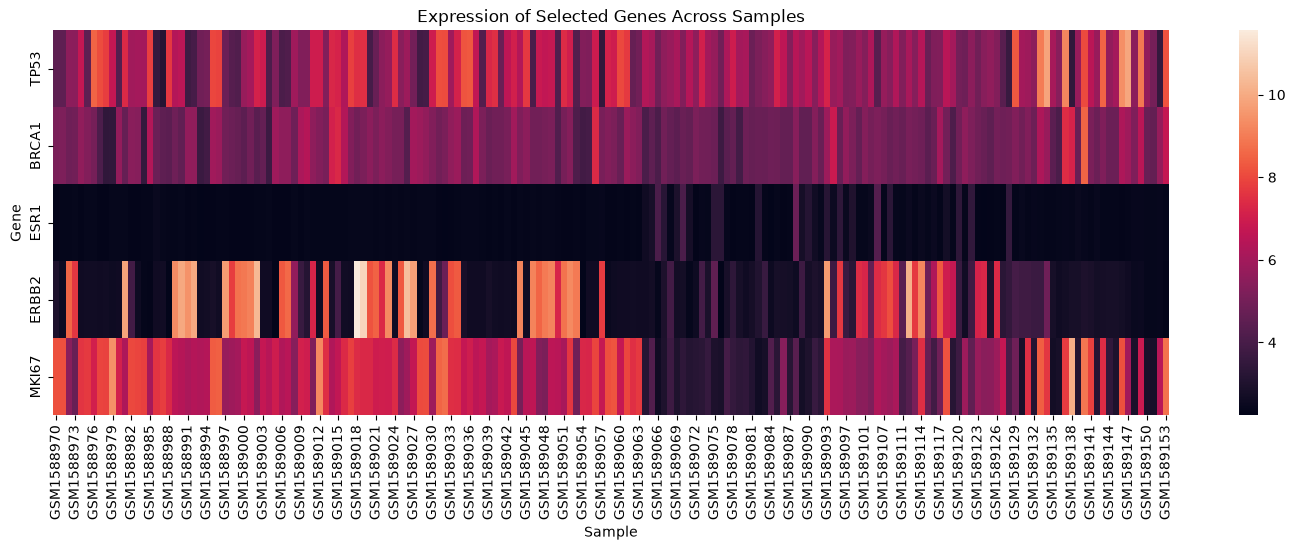

In [50]:
genes = [
    "TP53",
    "BRCA1",
    "ESR1",
    "ERBB2",
    "MKI67"
]

heatmap_df = expression_matrix.loc[genes]


plt.figure(figsize=(18, 5))

sns.heatmap(
    heatmap_df,
    annot=False
)

plt.title("Expression of Selected Genes Across Samples")
plt.xlabel("Sample")
plt.ylabel("Gene")

plt.show()

#### 📊 Interpretation of the above plot:

ESR1 shows relatively low expression across these samples, whereas MKI67 and TP53 show relatively lower expression.


Sample 2 shows relatively high expression for several genes, while Sample 3 has lower expression for some genes.


#### 🦠 Biological example8:

Do gene expression patterns differ across biological groups?


In [51]:
sample_groups = (
    analysis_df[["Sample_ID", "Group"]]
    .drop_duplicates()
    .set_index("Sample_ID")
)

In [52]:
sample_groups.head()

,Group
Sample_ID,
GSM1588970,TNBC
GSM1588971,TNBC
GSM1588972,Her2
GSM1588973,Her2
GSM1588974,TNBC


In [53]:
group_order = [
    "TNBC",
    "Her2",
    "Luminal A",
    "Luminal B",
    "Healthy",
    "CellLine"
]

In [54]:
sample_groups["Group"] = pd.Categorical(
    sample_groups["Group"],
    categories=group_order,
    ordered=True
)

sample_groups = sample_groups.sort_values("Group")

In [55]:
ordered_samples = sample_groups.index

expression_matrix = expression_matrix[ordered_samples]

In [56]:
group_labels = sample_groups.loc[expression_matrix.columns, "Group"]

In [69]:
sample_groups["Group"].unique()

['TNBC', 'Her2', 'Luminal A', 'Luminal B', 'Healthy', 'CellLine']
Categories (6, str): ['TNBC' < 'Her2' < 'Luminal A' < 'Luminal B' < 'Healthy' < 'CellLine']

Does ESR1 show higher expression in Luminal A/Luminal B samples compared with TNBC samples?


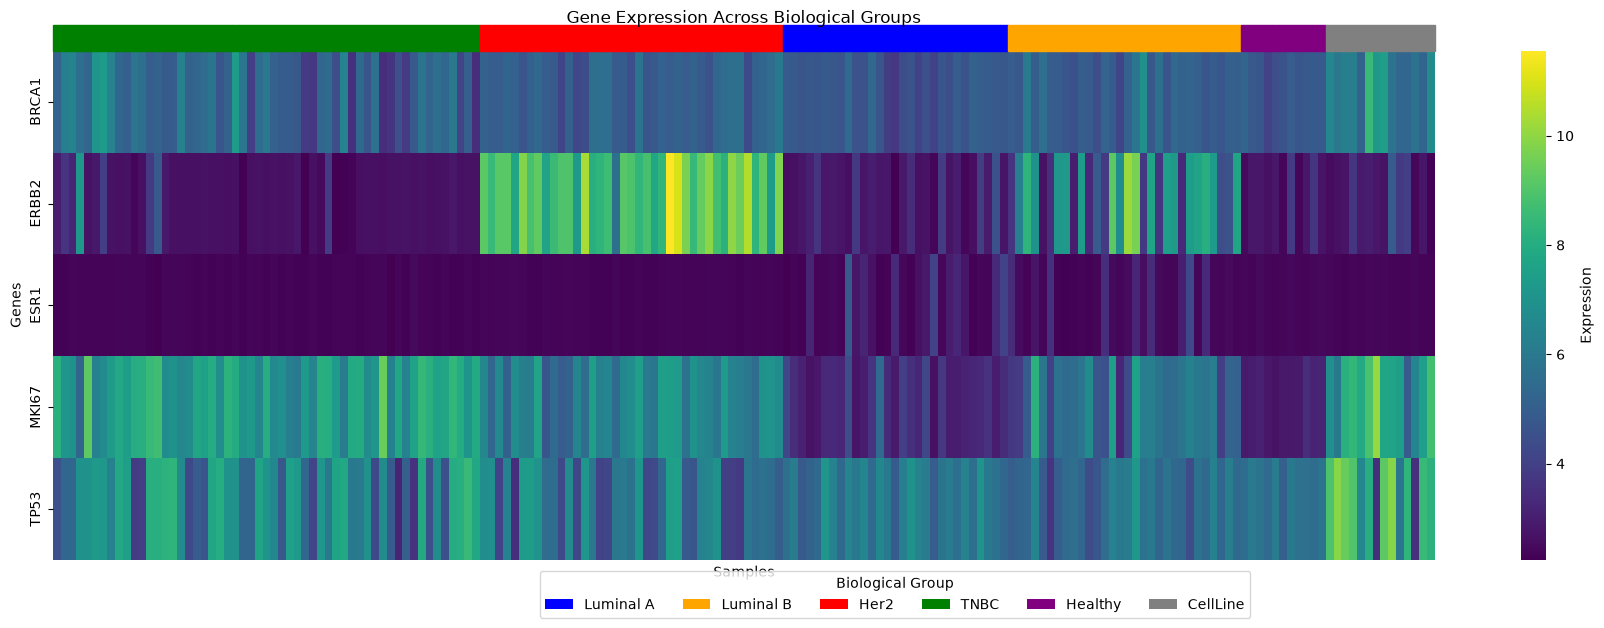

In [70]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(18, 6))


group_palette = {
    "Luminal A": "blue",
    "Luminal B": "orange",
    "Her2": "red",
    "TNBC": "green",
    "Healthy": "purple",
    "CellLine": "gray"
}

# Heatmap
sns.heatmap(
    expression_matrix,
    xticklabels=False,
    yticklabels=True,
    cmap="viridis",
    ax=ax,
    cbar_kws={"label": "Expression"}
)

# Group annotation بالای Heatmap
for i, group in enumerate(sample_groups["Group"]):
    ax.add_patch(
        plt.Rectangle(
            (i, -0.25),
            1,
            0.25,
            color=group_palette[group],
            transform=ax.transData,
            clip_on=False
        )
    )

# Legend برای Groupها
legend_handles = [
    Patch(facecolor=color, label=group)
    for group, color in group_palette.items()
]

fig.legend(
    handles=legend_handles,
    title="Biological Group",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=6
)

ax.set_title("Gene Expression Across Biological Groups", pad=20)
ax.set_xlabel("Samples")
ax.set_ylabel("Genes")

plt.tight_layout()
plt.show()

#### 📊 Interpretation of the above plot:

- **ESR1 (Estrogen Receptor):**  
  Highly expressed in **Luminal A** and **Luminal B** samples, but very low/absent in **TNBC**.  
  → This is the classic molecular pattern of breast cancer subtypes.

- **PGR (Progesterone Receptor):**  
  Shows a similar pattern to ESR1, but with **slightly lower** expression levels overall.

- **ERBB2 (HER2):**  
  Strongly overexpressed (bright yellow) in the **Her2** group, while remaining low in all other groups.

- **MKI67 (Proliferation Marker):**  
  Higher in **Luminal B** and **Her2** compared to **Luminal A**.  
  No clear difference between TNBC and other groups.

- **TP53 (Tumor Suppressor Gene):**  
  Shows higher expression in **TNBC** and some **CellLine** samples compared to Luminal subtypes.

#### Summary
The heatmap clearly demonstrates **distinct gene expression profiles** across breast cancer molecular subtypes.  
**ESR1** serves as a strong biomarker distinguishing **Luminal A/B** from **TNBC** samples.

### 6- Violin Plot — Comparing Distributions
Use it when:
You want to compare distributions across groups while also seeing their shape and density.

Main function:
```text
sns.violinplot(
    data=df,
    x="Group",
    y="Expression",
    inner="box"
)
```


| Argument | Meaning                       |
| -------- | ----------------------------- |
| `data`   | DataFrame                     |
| `x`      | Categorical variable          |
| `y`      | Numerical variable            |
| `hue`    | Additional category           |
| `inner`  | Show box/points inside violin |
| `cut`    | Control density extension     |


#### ❗️ Simple example10:

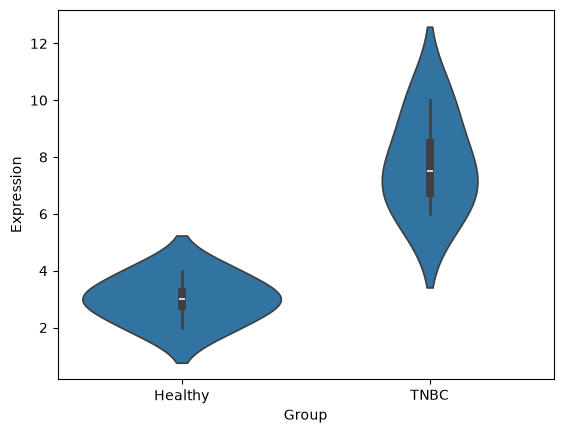

In [ ]:
df = pd.DataFrame({
    "Group": [
        "Healthy", "Healthy", "Healthy",
        "Healthy", "TNBC", "TNBC",
        "TNBC", "TNBC"
    ],
    "Expression": [
        2, 3, 3, 4,
        6, 7, 8, 10
    ]
})

sns.violinplot(
    data=df,
    x="Group",
    y="Expression"
)

plt.show()

#### 🦠 Biological example9:

How does the shape and density of ESR1 expression differ between biological groups?

In [ ]:
ESR1_df = analysis_df[
    analysis_df["Gene_Symbol_Clean"] == "ESR1"
].copy()

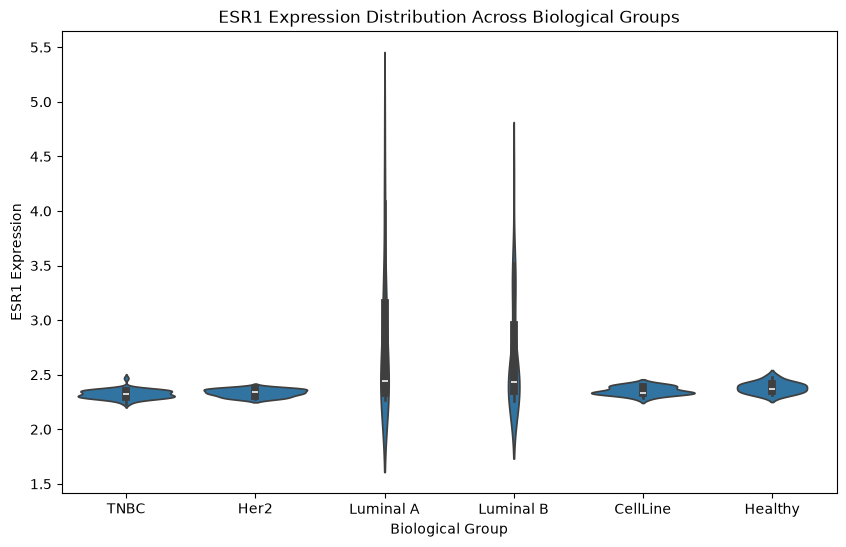

In [ ]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=ESR1_df,
    x="Group",
    y="Expression",
    inner="box"
)

plt.title("ESR1 Expression Distribution Across Biological Groups")
plt.xlabel("Biological Group")
plt.ylabel("ESR1 Expression")

plt.show()

#### 📊 Interpretation of the above plot:

ESR1 expression is relatively low and consistent in TNBC, Her2, CellLine, and Healthy, while Luminal A and Luminal B show greater variability and higher expression values. Luminal A has the widest distribution, indicating the highest heterogeneity.


#### 🦠 Biological example10:

How does the shape and density of ERBB2 expression differ between biological groups?

In [ ]:
ERBB2_df = analysis_df[
    analysis_df["Gene_Symbol_Clean"] == "ERBB2"
].copy()

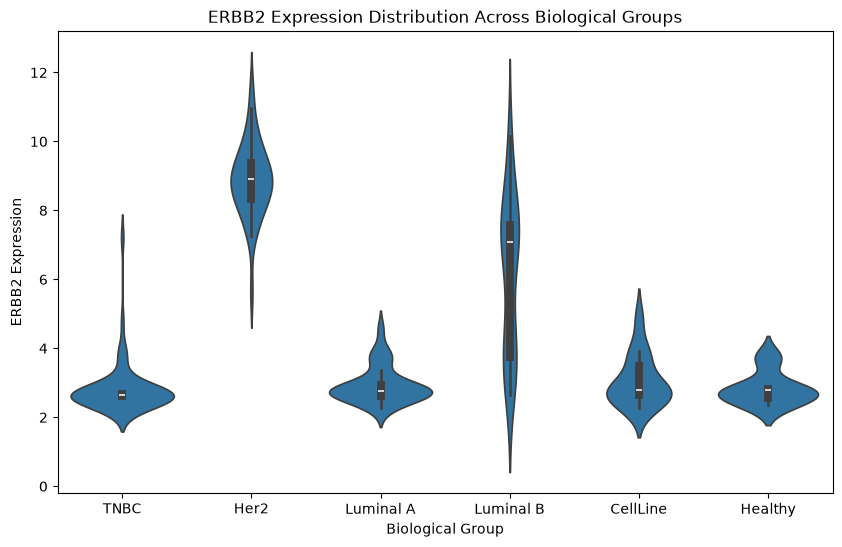

In [ ]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=ERBB2_df,
    x="Group",
    y="Expression",
    inner="box"
)

plt.title("ERBB2 Expression Distribution Across Biological Groups")
plt.xlabel("Biological Group")
plt.ylabel("ERBB2 Expression")

plt.show()

#### 📊 Interpretation of the above plot:

The Her2 group shows the highest and most densely packed ERBB2 expression, while Healthy and TNBC groups remain very low and narrow. Luminal A/B fall in between (with Luminal B slightly higher), and CellLines exhibit the widest, most variable distribution.



### Boxplot vs Violin Plot
| Feature                | Boxplot | Violin Plot               |
| ---------------------- | ------- | ------------------------- |
| **Median**             | ✅       | ✅                         |
| **Q1 / Q3**            | ✅       | —                         |
| **IQR**                | ✅       | —                         |
| **Outliers**           | ✅       | Usually shown differently |
| **Distribution shape** | Limited | ⭐⭐⭐                       |
| **Density**            | ❌       | ⭐⭐⭐                       |
| **Comparing groups**   | ⭐⭐⭐     | ⭐⭐⭐                       |


### barplot vs histplot


#### BarPlot :
```text
Category → Numerical value
sns.barplot(
    data=df,
    x="Group",
    y="Expression"
)
```
What is the average expression in each group?



#### Histogram Plot:
```text
Numerical → Distribution

sns.histplot(
    data=df,
    x="Expression"
)
```
In what areas do expressions accumulate the most?



### Seaborn Fundamentals
| Plot                   | Main Question                                                | Main Data          |
| ---------------------- | ------------------------------------------------------------ | ------------------ |
| 📦 `sns.boxplot()`     | How does the distribution differ across groups?              | Category + Numeric |
| 🔵 `sns.scatterplot()` | Is there a relationship between two variables?               | Numeric + Numeric  |
| 📊 `sns.histplot()`    | What does the distribution of a variable look like?          | Numeric            |
| 📊 `sns.barplot()`     | What is the value/mean for each group?                       | Category + Numeric |
| 🔥 `sns.heatmap()`     | How do values vary across a matrix?                          | Matrix             |
| 🎻 `sns.violinplot()`  | How does the shape of the distribution differ across groups? | Category + Numeric |


#### 📊 Final Exercise — Independent Biological Data Analysis
Choose a cancer-related GEO dataset and investigate the expression of selected genes across biological groups using Python.


Choose a cancer type other than breast cancer:
- Option A — Lung Cancer
- Option B — Colon Cancer
- Option C — Prostate Cancer

```text
GEO Dataset
     ↓
Download Data
     ↓
Explore Metadata
     ↓
Select Biological Groups
     ↓
Select 3–5 Genes
     ↓
Probe → Gene mapping
     ↓
Data Cleaning
     ↓
Missing Value Check
     ↓
Pandas DataFrame
     ↓
Exploratory Analysis
     ↓
Matplotlib / Seaborn
     ↓
Biological Interpretation
```